In [1]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

In [2]:
data_dir = 'C:/Users/Rodrigo/Desktop/VCPI-2526/train_images'

IMG_SIZE = 32
BATCH_SIZE = 64

In [3]:
from PIL import Image

img1 = Image.open(f"{data_dir}/00000/00000_00000.ppm")
img2 = Image.open(f"{data_dir}/00001/00010_00000.ppm")

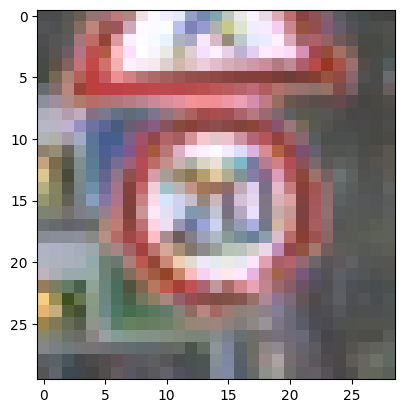

In [4]:
plt.imshow(img1)

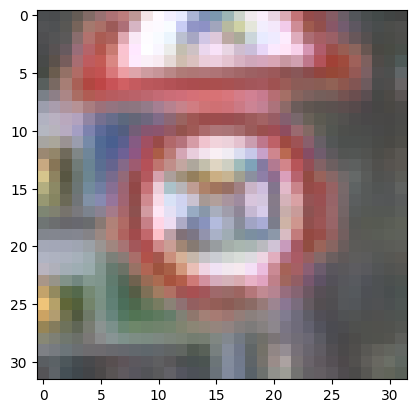

In [5]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE)), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)

plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

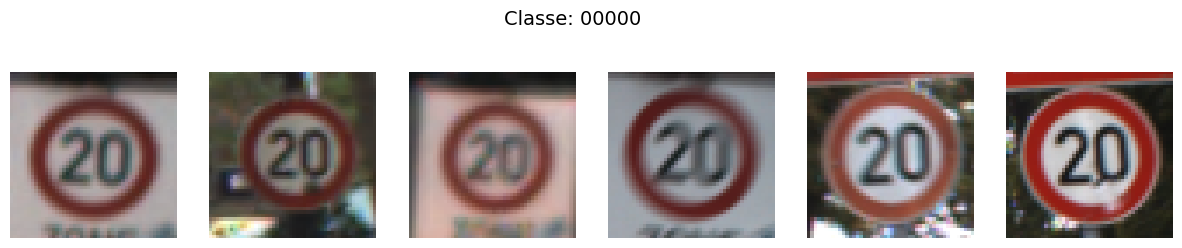

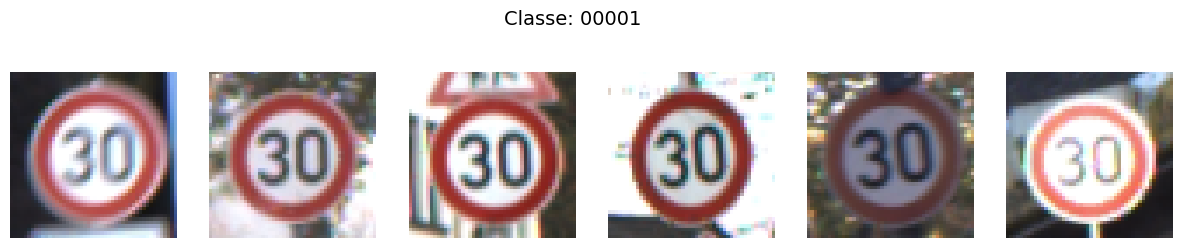

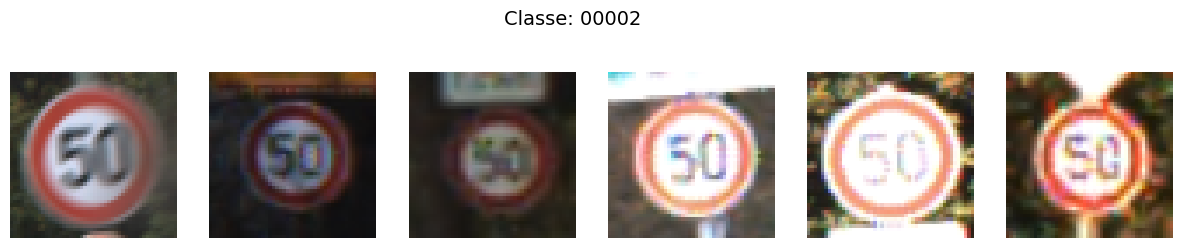

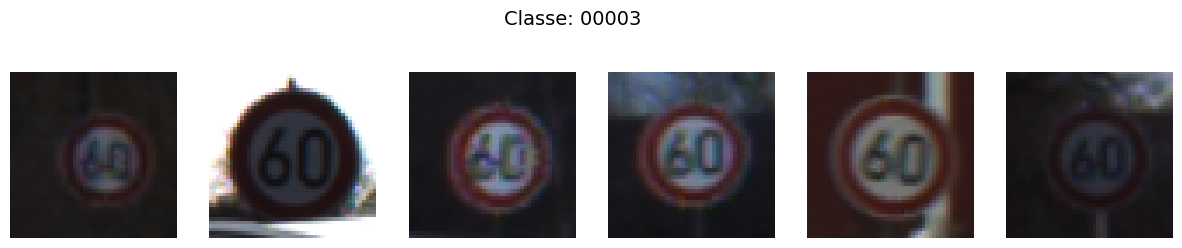

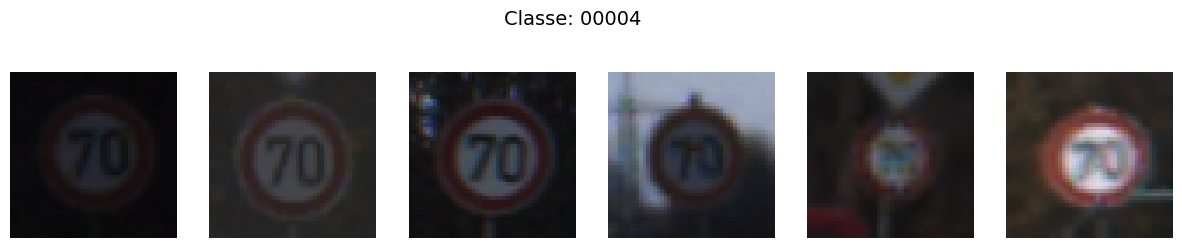

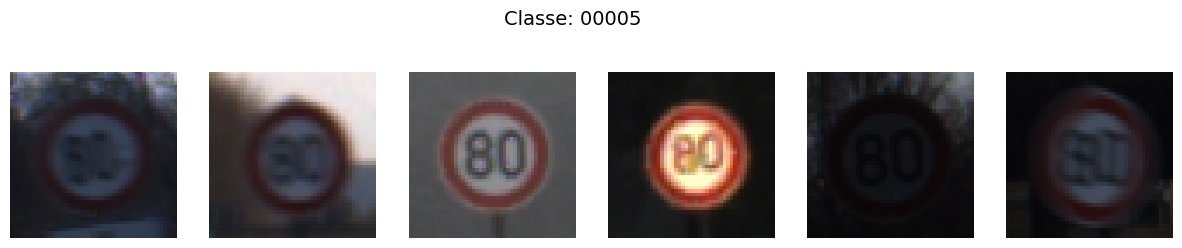

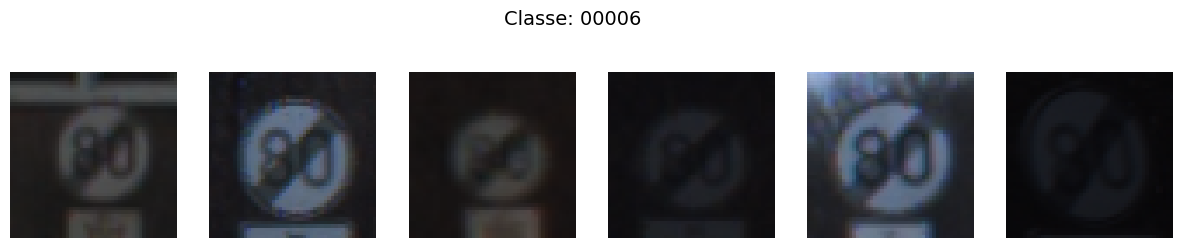

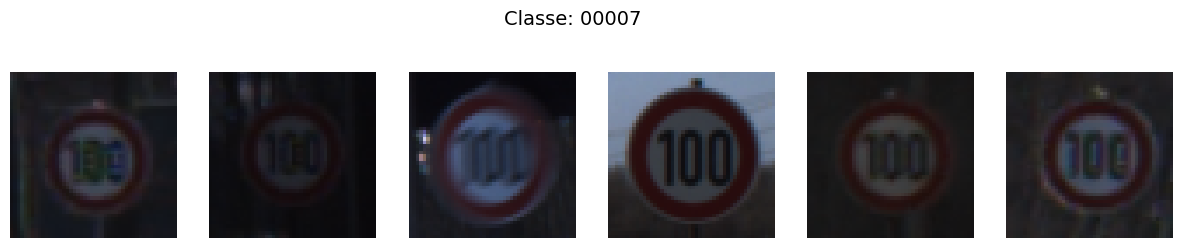

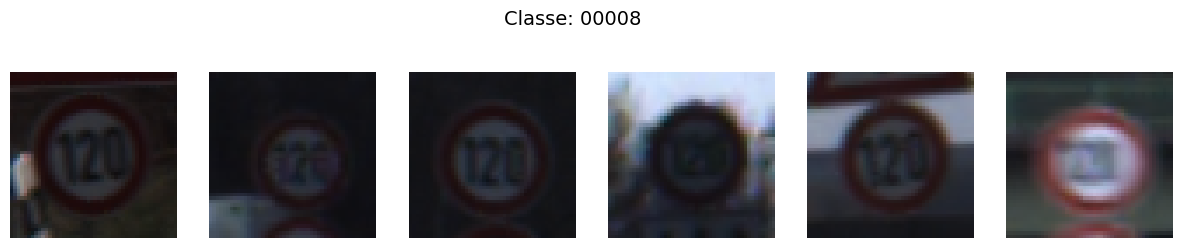

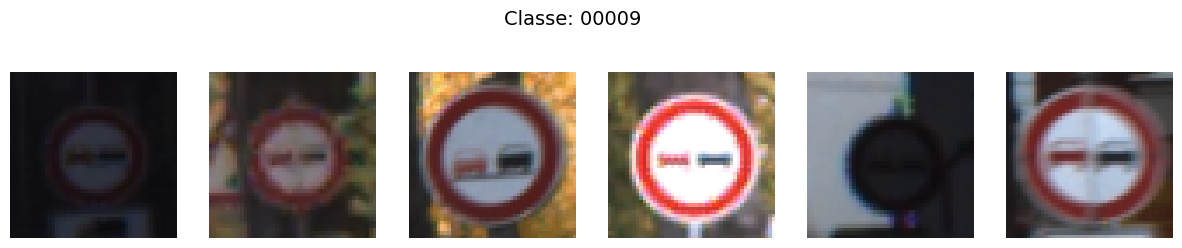

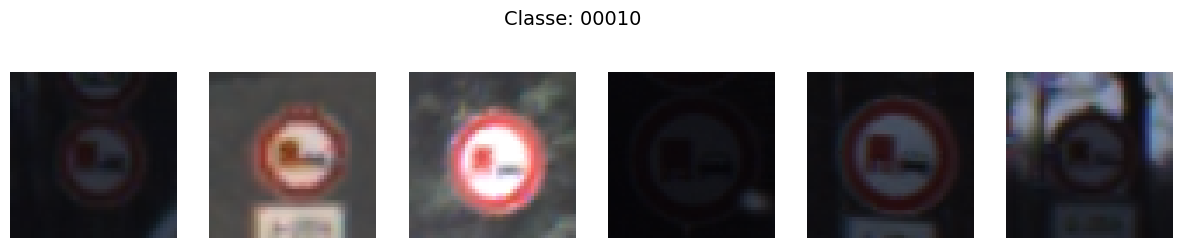

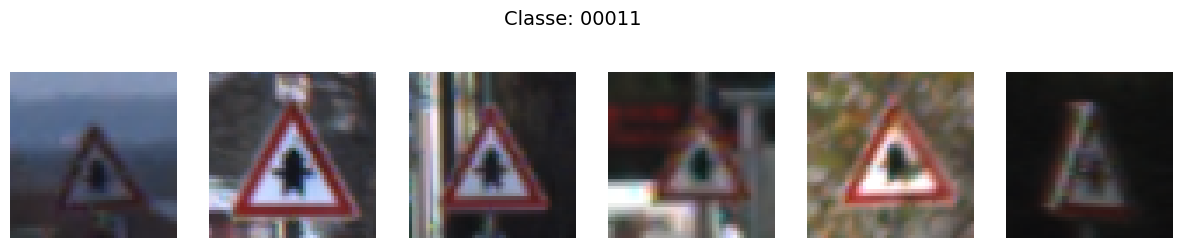

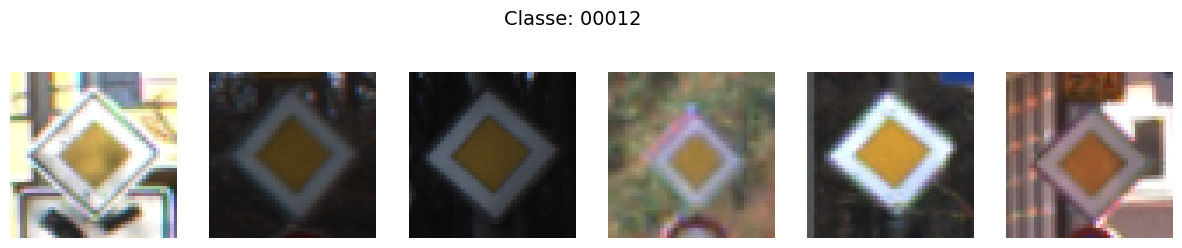

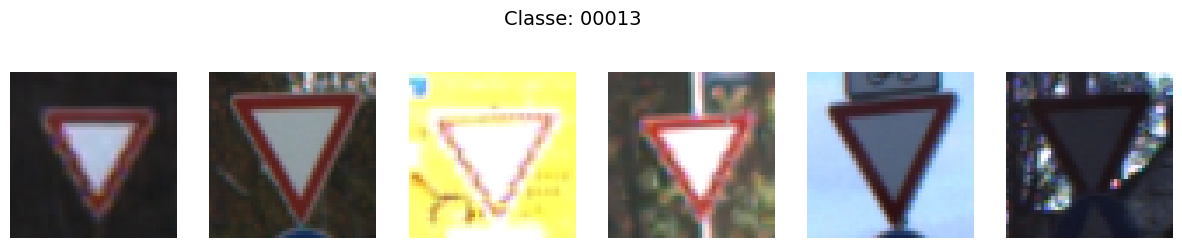

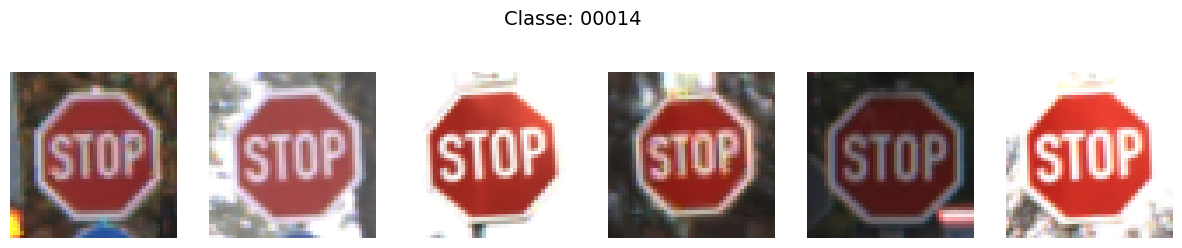

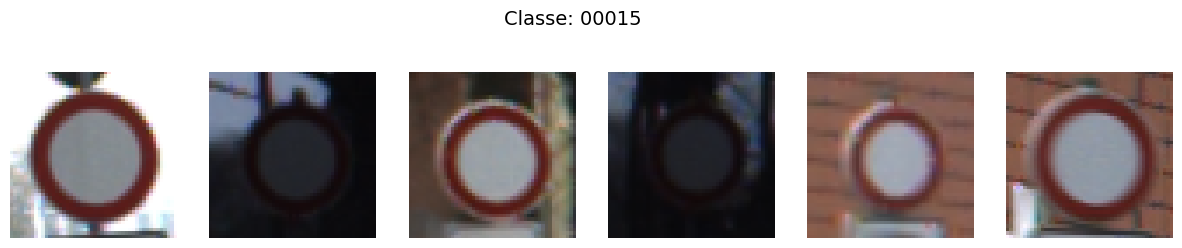

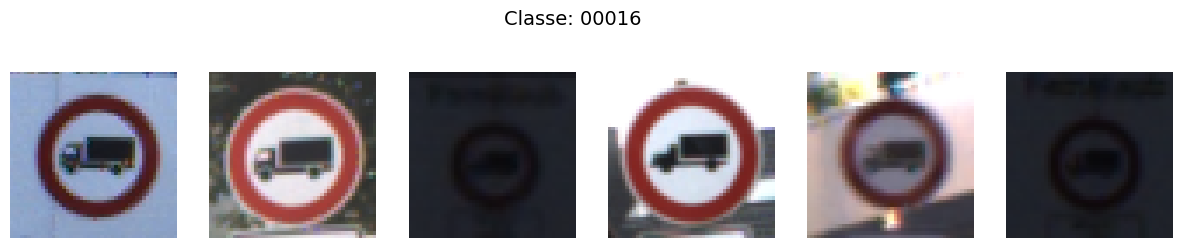

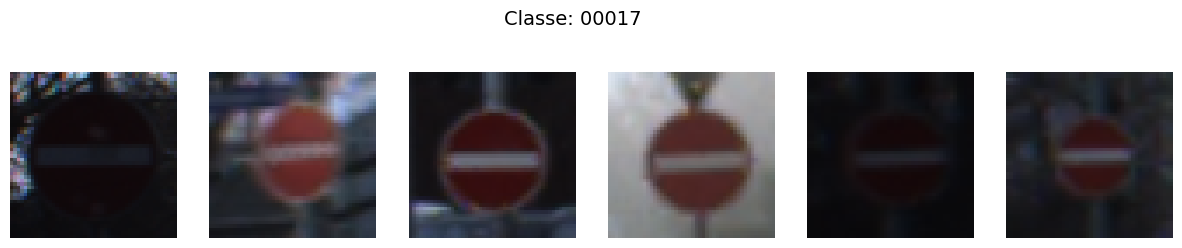

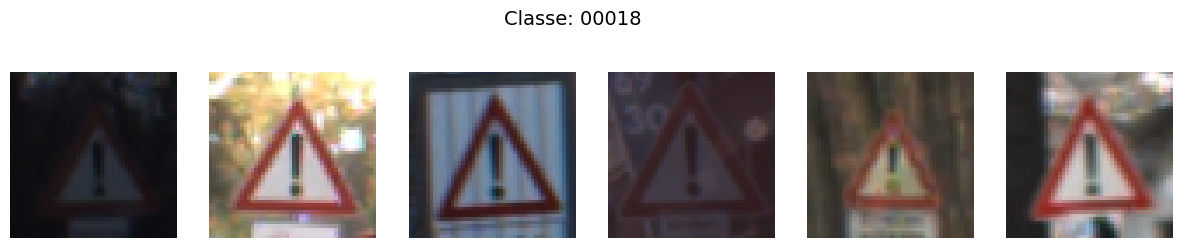

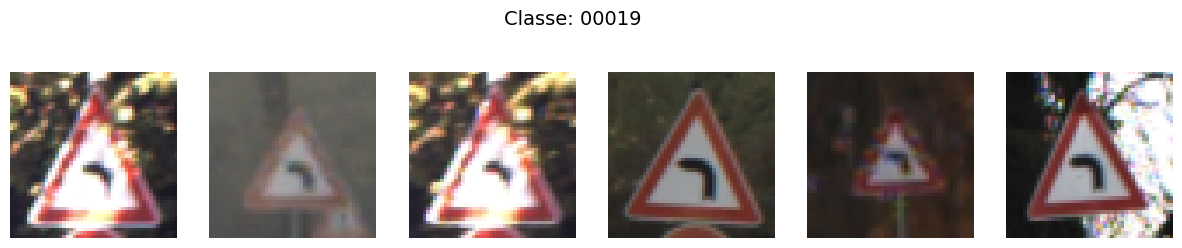

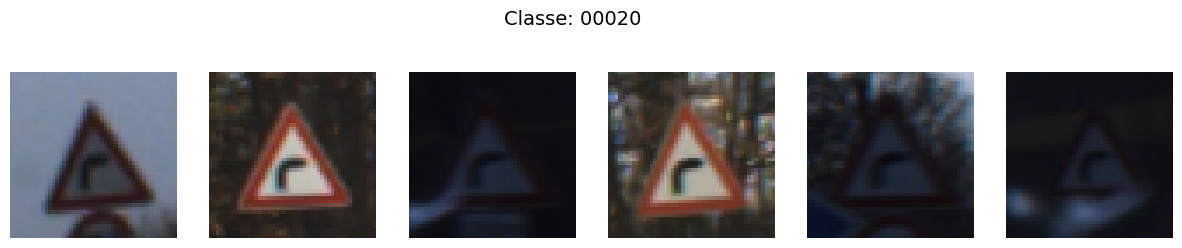

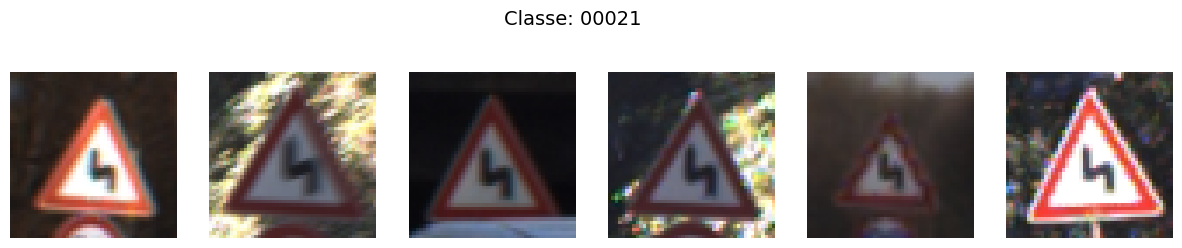

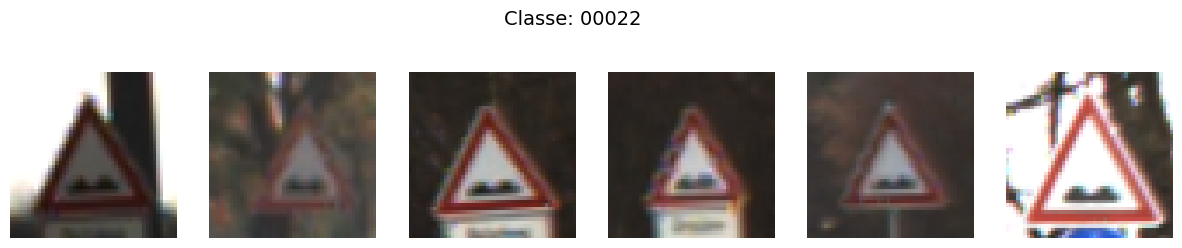

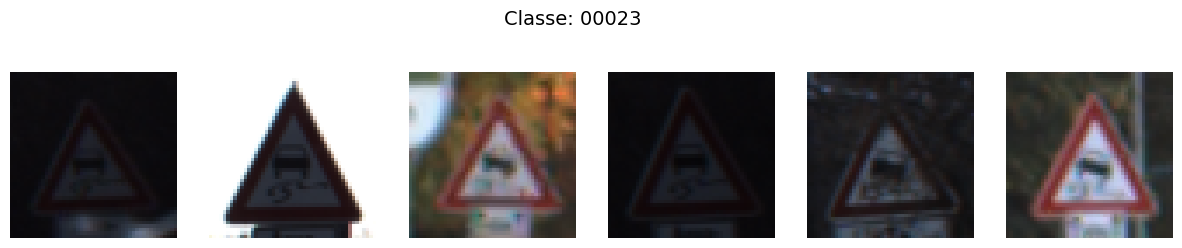

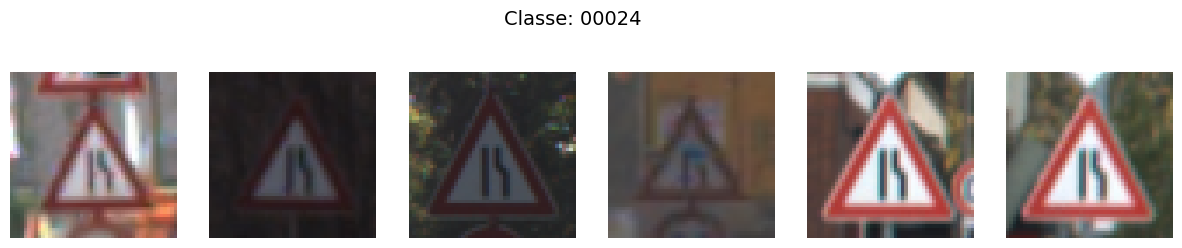

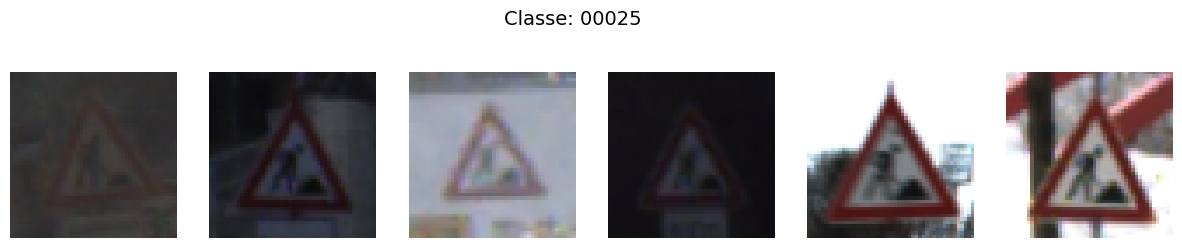

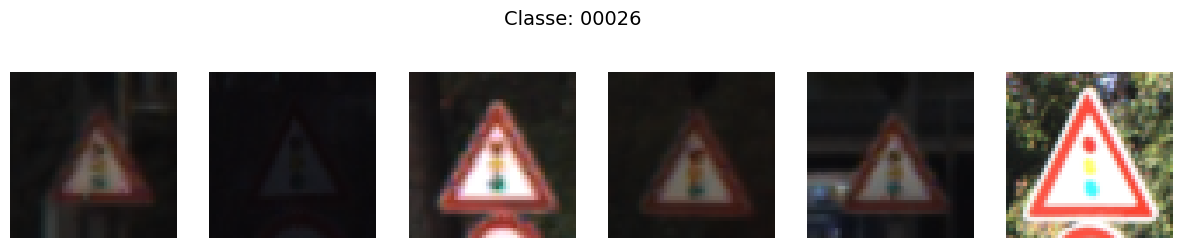

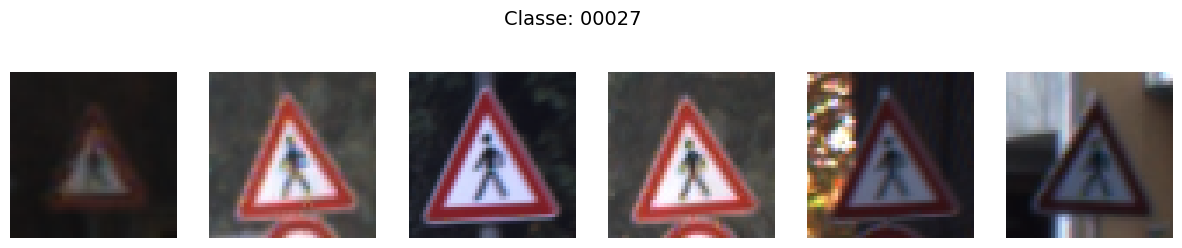

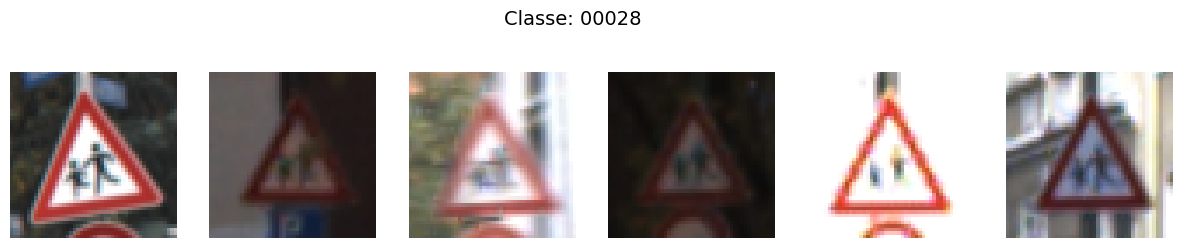

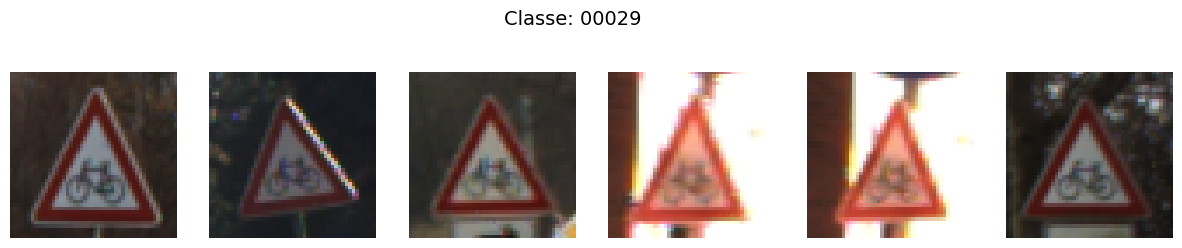

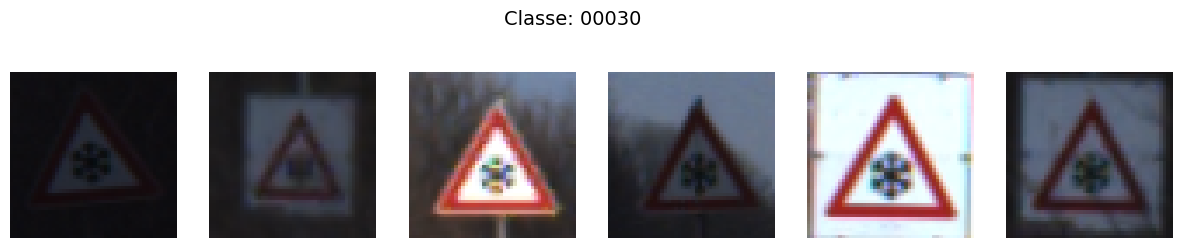

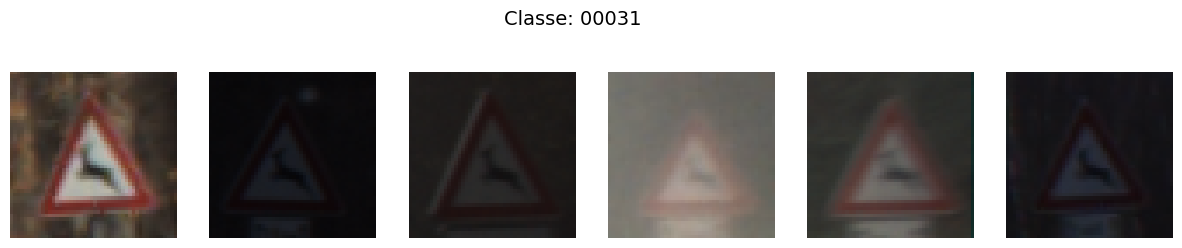

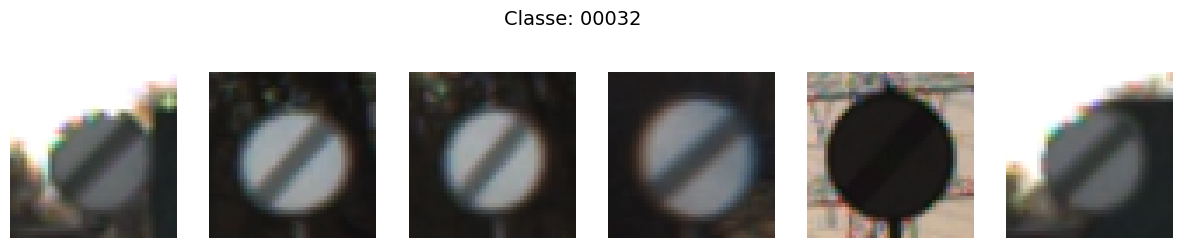

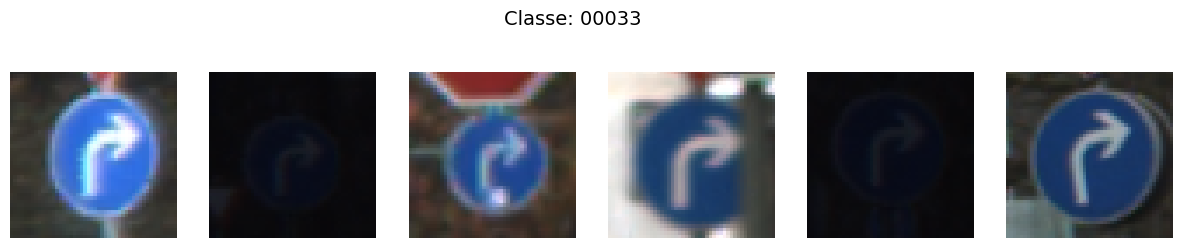

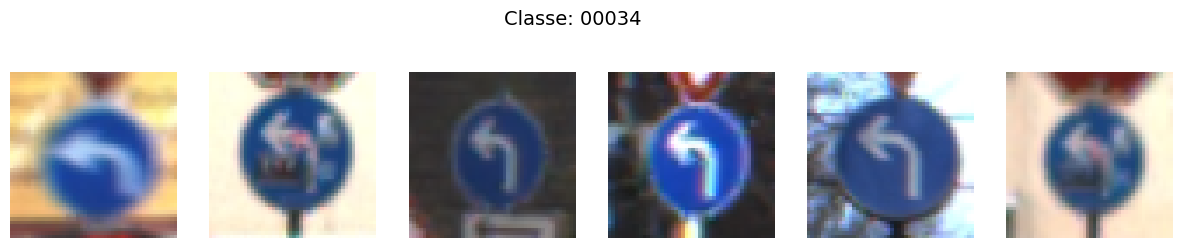

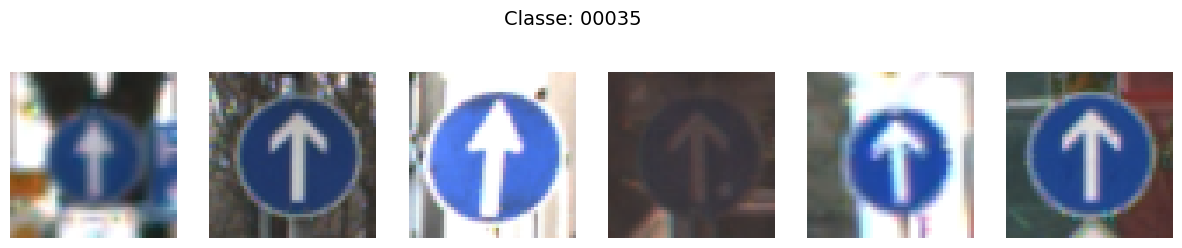

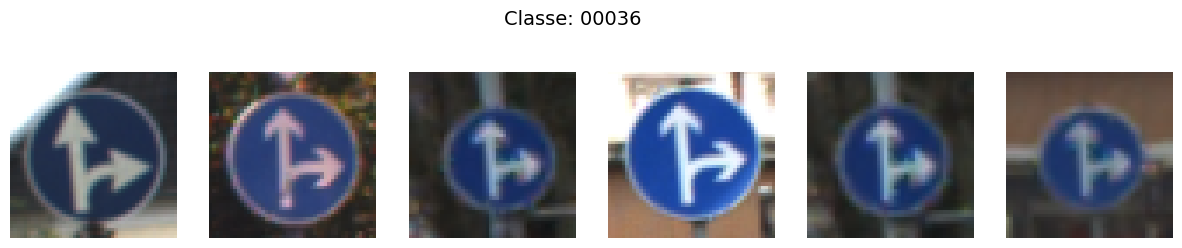

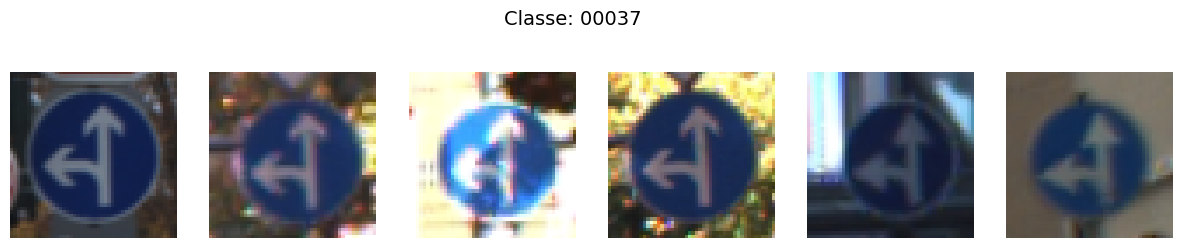

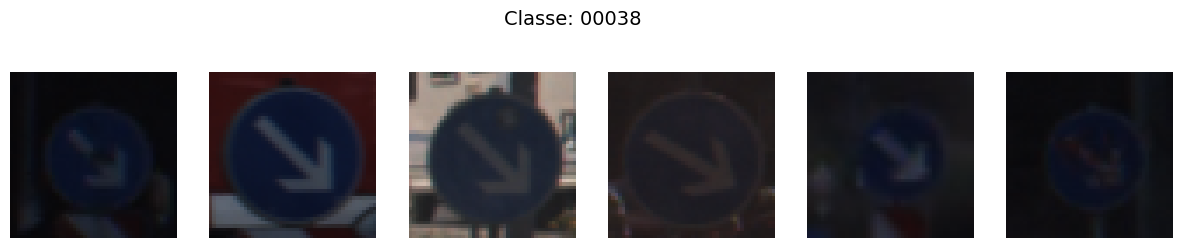

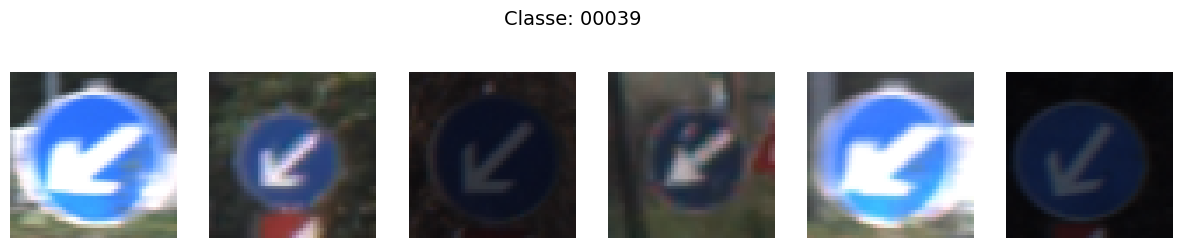

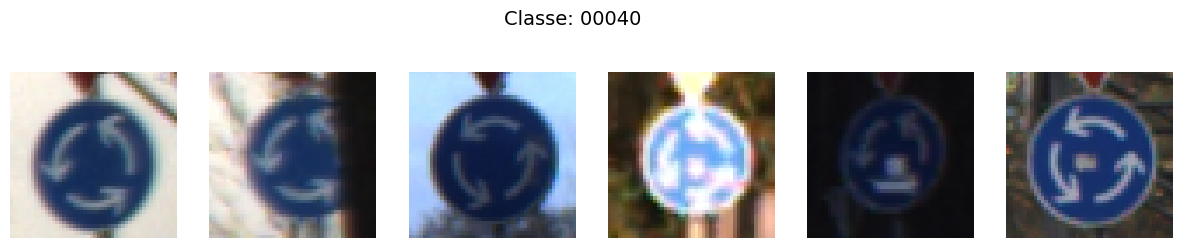

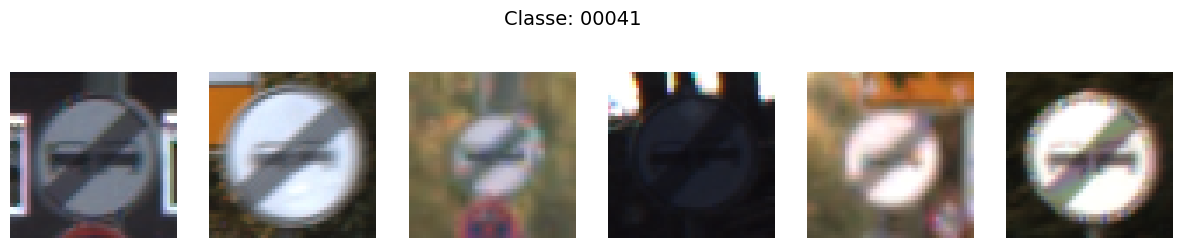

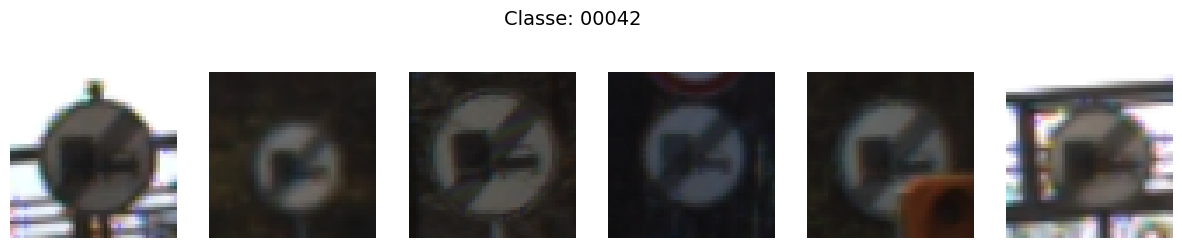

In [9]:
import random
import matplotlib.pyplot as plt
import torchvision

# Dataset sem transforms agressivas para visualizar corretamente
visual_transform = v2.Compose([
    v2.Resize((48, 48)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

visual_set = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=visual_transform
)

# classes
classes = visual_set.classes

# guardar índices por classe
class_indices = {i: [] for i in range(len(classes))}

for idx, (_, label) in enumerate(visual_set):
    class_indices[label].append(idx)

# mostrar 3 imagens aleatórias por classe
for class_id, class_name in enumerate(classes):

    random_idxs = random.sample(class_indices[class_id], 6)

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    fig.suptitle(f'Classe: {class_name}', fontsize=14)

    for i, idx in enumerate(random_idxs):

        image, label = visual_set[idx]

        # converter tensor -> numpy
        image = image.permute(1, 2, 0).numpy()

        axes[i].imshow(image)
        axes[i].axis('off')

    plt.show()

In [15]:
""" from PIL import Image
import os
from collections import Counter

data_dir = "train_images"

image_sizes = []

# percorrer todas as classes
for class_name in os.listdir(data_dir):

    class_path = os.path.join(data_dir, class_name)

    # garantir que é uma pasta
    if os.path.isdir(class_path):

        # percorrer imagens da classe
        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            try:
                img = Image.open(image_path)

                # guardar resolução (width, height)
                image_sizes.append(img.size)

            except:
                print(f"Erro ao abrir: {image_path}")

# contar ocorrências de cada resolução
resolution_counts = Counter(image_sizes)

# ordenar por frequência
resolution_counts = dict(
    sorted(
        resolution_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

# mostrar resultados
for resolution, count in resolution_counts.items():

    print(f"{resolution} -> {count}") """

' from PIL import Image\nimport os\nfrom collections import Counter\n\ndata_dir = "train_images"\n\nimage_sizes = []\n\n# percorrer todas as classes\nfor class_name in os.listdir(data_dir):\n\n    class_path = os.path.join(data_dir, class_name)\n\n    # garantir que é uma pasta\n    if os.path.isdir(class_path):\n\n        # percorrer imagens da classe\n        for image_name in os.listdir(class_path):\n\n            image_path = os.path.join(class_path, image_name)\n\n            try:\n                img = Image.open(image_path)\n\n                # guardar resolução (width, height)\n                image_sizes.append(img.size)\n\n            except:\n                print(f"Erro ao abrir: {image_path}")\n\n# contar ocorrências de cada resolução\nresolution_counts = Counter(image_sizes)\n\n# ordenar por frequência\nresolution_counts = dict(\n    sorted(\n        resolution_counts.items(),\n        key=lambda x: x[1],\n        reverse=True\n    )\n)\n\n# mostrar resultados\nfor resolu

In [16]:
from PIL import Image
import os
from collections import Counter
import numpy as np

data_dir = "train_images"

image_sizes = []

# -----------------------------------
# Percorrer dataset
# -----------------------------------
for class_name in os.listdir(data_dir):

    class_path = os.path.join(data_dir, class_name)

    # garantir que é diretório
    if os.path.isdir(class_path):

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            try:
                img = Image.open(image_path)

                # guardar resolução
                image_sizes.append(img.size)

            except:
                print(f"Erro ao abrir: {image_path}")

# -----------------------------------
# Contagem de resoluções
# -----------------------------------
resolution_counts = Counter(image_sizes)

resolution_counts = dict(
    sorted(
        resolution_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

# -----------------------------------
# Mostrar resoluções mais frequentes
# -----------------------------------
print("Resoluções mais frequentes:\n")

for resolution, count in resolution_counts.items():

    print(f"{resolution} -> {count}")

# -----------------------------------
# Cálculo da média
# -----------------------------------
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

avg_width = np.mean(widths)
avg_height = np.mean(heights)

print("\n-----------------------------------")
print("Média das resoluções")
print("-----------------------------------")

print(f"Largura média : {avg_width:.2f}")
print(f"Altura média  : {avg_height:.2f}")

# -----------------------------------
# Estatísticas adicionais (úteis)
# -----------------------------------
print("\n-----------------------------------")
print("Outras estatísticas")
print("-----------------------------------")

print(f"Menor largura : {min(widths)}")
print(f"Maior largura : {max(widths)}")

print(f"Menor altura  : {min(heights)}")
print(f"Maior altura  : {max(heights)}")

print(f"\nTotal imagens : {len(image_sizes)}")

Erro ao abrir: train_images\00012\GT-00012.csv
Resoluções mais frequentes:

(31, 31) -> 354
(30, 30) -> 337
(35, 35) -> 324
(38, 38) -> 320
(33, 33) -> 316
(29, 29) -> 314
(32, 32) -> 313
(34, 34) -> 305
(36, 36) -> 303
(30, 31) -> 299
(32, 33) -> 292
(33, 34) -> 286
(37, 37) -> 283
(40, 40) -> 271
(29, 30) -> 257
(35, 36) -> 250
(34, 35) -> 250
(31, 32) -> 248
(43, 43) -> 246
(39, 39) -> 238
(28, 28) -> 238
(34, 33) -> 236
(36, 37) -> 232
(41, 41) -> 228
(38, 39) -> 225
(28, 29) -> 222
(31, 30) -> 218
(35, 34) -> 215
(40, 41) -> 212
(39, 40) -> 212
(37, 38) -> 210
(33, 32) -> 205
(32, 31) -> 203
(37, 36) -> 194
(42, 42) -> 193
(30, 29) -> 187
(27, 28) -> 177
(36, 35) -> 175
(27, 27) -> 173
(38, 37) -> 166
(39, 38) -> 166
(44, 44) -> 164
(41, 42) -> 161
(40, 39) -> 154
(29, 28) -> 154
(45, 45) -> 147
(41, 40) -> 143
(46, 46) -> 142
(48, 48) -> 140
(42, 43) -> 139
(44, 45) -> 139
(30, 32) -> 138
(34, 36) -> 136
(42, 41) -> 136
(43, 42) -> 133
(46, 47) -> 128
(47, 47) -> 127
(31, 33) -> 

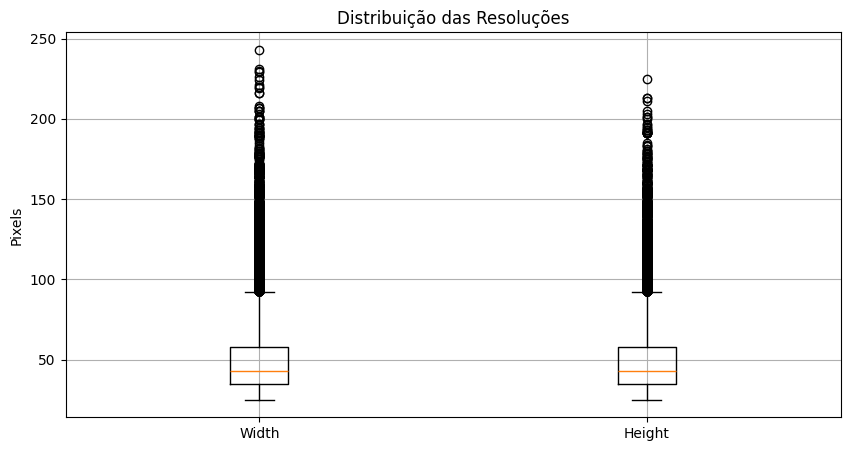

Median width  : 43.00
Median height : 43.00


In [17]:
# -----------------------------------
# Boxplot das resoluções
# -----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(
    [widths, heights],
    tick_labels=["Width", "Height"]
)

plt.title("Distribuição das Resoluções")
plt.ylabel("Pixels")

plt.grid(True)

plt.show()

print(f"Median width  : {np.median(widths):.2f}")
print(f"Median height : {np.median(heights):.2f}")

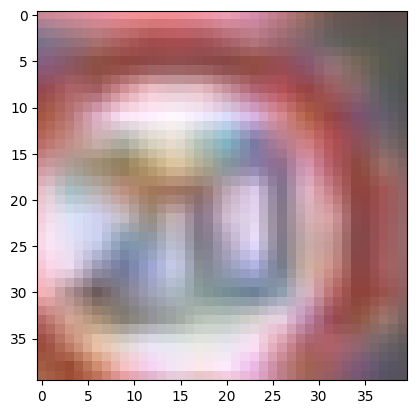

In [18]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE+50,IMG_SIZE+50), antialias=True), 
    v2.RandomCrop(size=(40, 40)),
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

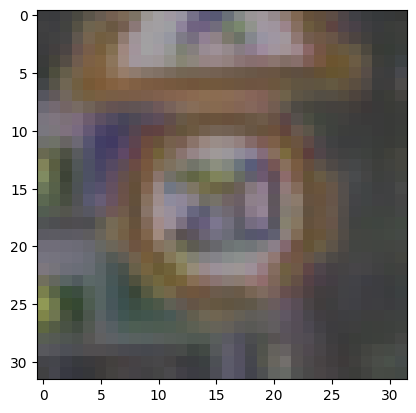

In [19]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ColorJitter(brightness = 0.5, contrast = 0.5,saturation = 0.2, hue = 0.2), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

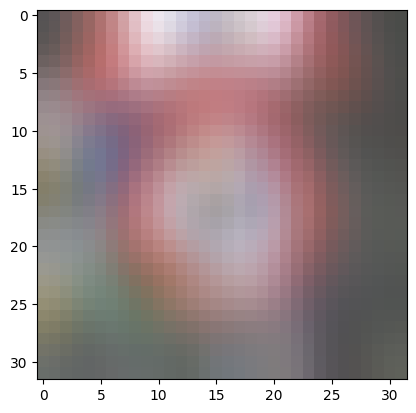

In [20]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

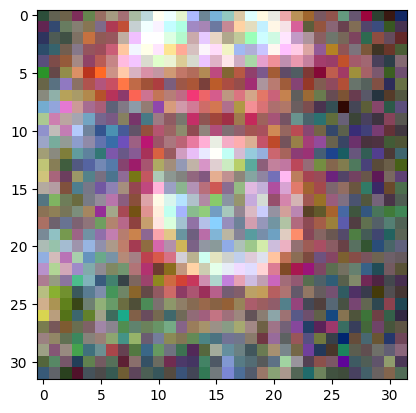

In [21]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.GaussianNoise(mean=0.0, sigma=0.1, clip=0.5),
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9500673..3.4284973].


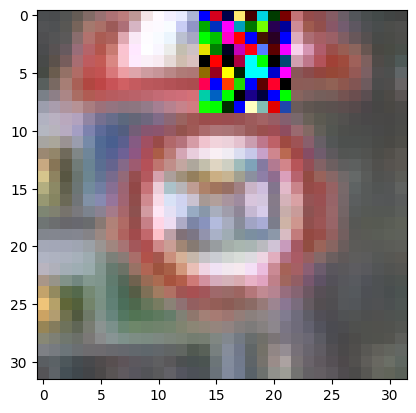

In [22]:
transformB = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(1, scale=(0.05,0.1), value='random')    
])

transf_img = transformB(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

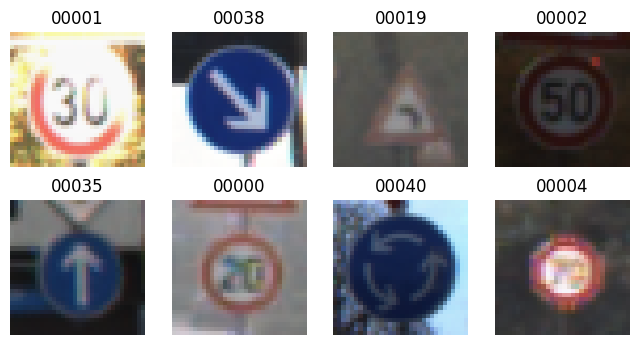

<Figure size 640x480 with 0 Axes>

Soft labels (MixUp):
tensor([[0.0000, 0.9748, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0252, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.9748, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0252, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])


In [23]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Transform base
# -------------------------
transform = v2.Compose([

    v2.ToImage(),

    v2.Resize(
        (IMG_SIZE, IMG_SIZE),
        antialias=True
    ),

    v2.ToDtype(
        torch.float32,
        scale=True
    )
])

# -------------------------
# Dataset + loader
# -------------------------
train_set = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -------------------------
# MixUp (CORRIGIDO)
# -------------------------
mixup = v2.MixUp(num_classes=43, alpha=1.0)

# get batch
imgs, labels = next(iter(train_loader))

# apply mixup (batch level)
imgs2, labels2 = mixup(imgs, labels)

# -------------------------
# visualization
# -------------------------
vcpi_util.show_images(
    2,
    4,
    imgs2,
    labels,   # opcional (não ideal)
    train_set.classes
)

print("Soft labels (MixUp):")
print(labels2)

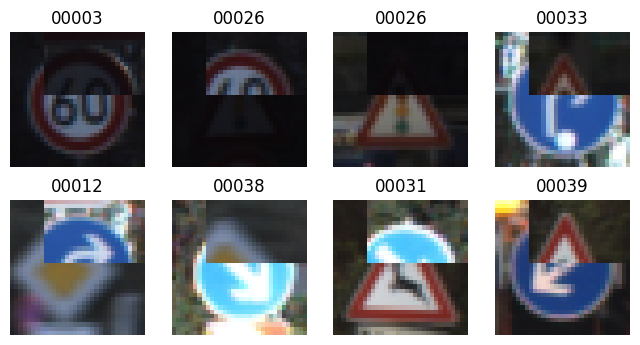

<Figure size 640x480 with 0 Axes>

Soft labels (CutMix):
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6484, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3516, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])


In [24]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Base transform
# -------------------------
transform = v2.Compose([

    v2.ToImage(),

    v2.Resize(
        (IMG_SIZE, IMG_SIZE),
        antialias=True
    ),

    v2.ToDtype(
        torch.float32,
        scale=True
    )
])

# -------------------------
# Dataset
# -------------------------
train_set = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -------------------------
# CutMix (CORRIGIDO)
# -------------------------
cutmix = v2.CutMix(num_classes=43, alpha=1.0)

imgs, labels = next(iter(train_loader))

imgs2, labels2 = cutmix(imgs, labels)

# -------------------------
# Visualization
# -------------------------
vcpi_util.show_images(
    2,
    4,
    imgs2,
    labels,   # opcional, mas não ideal
    train_set.classes
)

print("Soft labels (CutMix):")
print(labels2)

In [29]:
def show_bad_preds(model, dataset, classes):

    model.eval()

    k = 0
    preds = []
    ground_truth = []

    imgs = torch.Tensor(52, 3, IMG_SIZE, IMG_SIZE)

    with torch.no_grad():

        for images, targets in dataset:

            images = images.to(device)

            logits = model(images)

            predictions = torch.nn.functional.softmax(
                logits,
                dim=1
            ).cpu().detach().numpy()

            for i in range(len(predictions)):

                pred_class = np.argmax(predictions[i])

                if pred_class != targets[i] and k < 52:

                    preds.append(predictions[i])

                    ground_truth.append(targets[i])

                    imgs[k] = images[i].cpu()

                    k += 1

            if k >= 52:
                break

    vcpi_util.plot_predictions(
        imgs,
        preds,
        ground_truth,
        classes,
        13,
        4
    )



def train_III(
    model,
    train_loader,
    val_loader,
    epochs,
    loss_fn,
    optimizer,
    scheduler,
    early_stopper,
    save_prefix='model'
):

    history = {}

    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []

    best_val_loss = np.inf

    for epoch in range(epochs):

        # ---------------------------------
        # TRAIN
        # ---------------------------------

        model.train()

        start_time = time.time()

        correct = 0

        running_loss = 0.0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)

            targets = targets.to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            correct += (predicted == targets).sum()

        # ---------------------------------
        # VALIDATION
        # ---------------------------------

        model.eval()

        with torch.no_grad():

            v_correct = 0

            val_loss = 0.0

            for inputs, targets in val_loader:

                inputs = inputs.to(device)

                targets = targets.to(device)

                outputs = model(inputs)

                _, preds = torch.max(outputs, 1)

                val_loss += loss_fn(
                    outputs,
                    targets
                ).item() * targets.size(0)

                v_correct += (preds == targets).sum()

        # ---------------------------------
        # LR SCHEDULER
        # ---------------------------------

        old_lr = optimizer.param_groups[0]['lr']

        scheduler.step(val_loss)

        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:

            print(
                '==> Learning rate updated:',
                old_lr,
                '->',
                new_lr
            )

        # ---------------------------------
        # METRICS
        # ---------------------------------

        epoch_loss = running_loss / len(train_loader.dataset)

        accuracy = (
            100 * correct / len(train_loader.dataset)
        )

        v_accuracy = (
            100 * v_correct / len(val_loader.dataset)
        )

        val_loss = val_loss / len(val_loader.dataset)

        stop_time = time.time()

        print(
            f'Epoch: {epoch:03d}; '
            f'Loss: {epoch_loss:0.6f}; '
            f'Accuracy: {accuracy:0.4f}; '
            f'Val Loss: {val_loss:0.6f}; '
            f'Val Acc: {v_accuracy:0.4f}; '
            f'Elapsed time: {(stop_time - start_time):0.4f}'
        )

        # ---------------------------------
        # HISTORY
        # ---------------------------------

        history['accuracy'].append(
            accuracy.cpu().numpy()
        )

        history['val_acc'].append(
            v_accuracy.cpu().numpy()
        )

        history['val_loss'].append(
            val_loss
        )

        history['loss'].append(
            epoch_loss
        )

        # ---------------------------------
        # SAVE BEST MODEL
        # ---------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    'epoch': epoch,
                    'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}.pt'
            )

        # ---------------------------------
        # EARLY STOPPING
        # ---------------------------------

        if early_stopper(val_loss):

            print('Early stopping!')

            break

    print('Finished Training')

    return history



def evaluate(model, data_loader):

    model.eval()

    correct = 0

    with torch.no_grad():

        for images, targets in data_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, dim=1)

            correct += (
                preds.cpu() == targets
            ).sum()

    return (
        correct / len(data_loader.dataset)
    ).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # ---------------------------------
        # BLOCK 1
        # ---------------------------------

        self.conv1 = torch.nn.Conv2d(
            3,
            32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = torch.nn.BatchNorm2d(32)

        self.relu1 = torch.nn.ReLU()


        self.conv2 = torch.nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = torch.nn.BatchNorm2d(64)

        self.relu2 = torch.nn.ReLU()


        self.maxpool1 = torch.nn.MaxPool2d(2)

        # ---------------------------------
        # BLOCK 2
        # ---------------------------------

        self.conv3 = torch.nn.Conv2d(
            64,
            128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = torch.nn.BatchNorm2d(128)

        self.relu3 = torch.nn.ReLU()


        self.conv4 = torch.nn.Conv2d(
            128,
            128,
            kernel_size=3,
            padding=1
        )

        self.bn4 = torch.nn.BatchNorm2d(128)

        self.relu4 = torch.nn.ReLU()


        self.maxpool2 = torch.nn.MaxPool2d(2)

        # ---------------------------------
        # DROPOUT
        # ---------------------------------

        self.dropout = torch.nn.Dropout(0.3)

        # ---------------------------------
        # FINAL CLASSIFIER
        # ---------------------------------

        self.fc1 = torch.nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        # INPUT:
        # (bs, 3, 48, 48)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        # (bs, 32, 48, 48)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        # (bs, 64, 48, 48)

        x = self.maxpool1(x)

        # (bs, 64, 24, 24)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        # (bs, 128, 24, 24)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)

        # (bs, 128, 24, 24)

        x = self.maxpool2(x)

        # (bs, 128, 12, 12)

        # ---------------------------------
        # GLOBAL AVERAGE POOLING
        # ---------------------------------

        x = torch.mean(
            x,
            dim=[2, 3]
        )

        # (bs, 128)

        # ---------------------------------
        # DROPOUT
        # ---------------------------------

        x = self.dropout(x)

        # ---------------------------------
        # FINAL CLASSIFIER
        # ---------------------------------

        x = self.fc1(x)

        return x



class Early_Stopping():

    def __init__(
        self,
        patience=3,
        min_delta=0.00001
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.counter = 0

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement

        if val_loss + self.min_delta < self.min_val_loss:

            self.min_val_loss = val_loss

            self.counter = 0

        # no improvement

        else:

            self.counter += 1

            if self.counter > self.patience:

                return True

        return False

In [37]:
device = torch.device(
    'cuda:0' if torch.cuda.is_available() else 'cpu'
)

print(device)

BASE_PATH = 'C:/Users/Rodrigo/Desktop/VCPI-2526'

PATH_TRAINING_SET = f'{BASE_PATH}/train_images'
PATH_TEST_SET = f'{BASE_PATH}/test_images'

BATCH_SIZE = 32

IMG_SIZE = 48

EPOCHS = 50

RUNS = 5

cuda:0


In [38]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
import numpy as np

# -----------------------------------
# DEVICE
# -----------------------------------
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

# -----------------------------------
# PATHS (GTSRB STRUCTURE)
# -----------------------------------
BASE_PATH = 'C:/Users/Rodrigo/Desktop/VCPI-2526'

PATH_TRAINING_SET = f'{BASE_PATH}/train_images'
PATH_TEST_SET = f'{BASE_PATH}/test_images'

# -----------------------------------
# HYPERPARAMETERS
# -----------------------------------
BATCH_SIZE = 32
IMG_SIZE = 48

# -----------------------------------
# TRANSFORM (BASE)
# -----------------------------------
transform = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

# -----------------------------------
# TRAIN FULL DATASET (ImageFolder entende pastas como classes)
# -----------------------------------
full_train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform
)

# -----------------------------------
# TRAIN / VALIDATION SPLIT
# -----------------------------------
indices = np.random.permutation(len(full_train_set))

split = int(0.8 * len(indices))

train_indices = indices[:split]
val_indices = indices[split:]

train_set = Subset(full_train_set, train_indices)
val_set = Subset(full_train_set, val_indices)

# -----------------------------------
# DATA LOADERS
# -----------------------------------
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# -----------------------------------
# TEST SET (NÃO TOCAR)
# -----------------------------------
test_set = torchvision.datasets.ImageFolder(
    root=PATH_TEST_SET,
    transform=transform
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# -----------------------------------
# CLASSES (IMPORTANTE PARA GTSRB)
# -----------------------------------
classes = full_train_set.classes
num_classes = len(classes)

print("Num classes:", num_classes)
print("Example classes:", classes[:5])

cuda:0
Num classes: 43
Example classes: ['00000', '00001', '00002', '00003', '00004']


In [39]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'gtsrb_balanced_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

AttributeError: 'Subset' object has no attribute 'classes'

In [ ]:
transform_aug = v2.Compose(
    [v2.Resize((48,48)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05], interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(brightness = 0.5, contrast = 0.5,hue = 0.1),
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform_aug)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

In [41]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'aug_I_{i}')

Epoch: 000; Loss: 2.402017; Accuracy: 31.4595; Val Loss: 2.410602; Val Acc: 32.2489; Elapsed time: 47.9464
Epoch: 001; Loss: 1.075071; Accuracy: 69.0384; Val Loss: 1.552989; Val Acc: 55.1627; Elapsed time: 46.6325
Epoch: 002; Loss: 0.442001; Accuracy: 88.7204; Val Loss: 1.742514; Val Acc: 50.9618; Elapsed time: 46.3400
Epoch: 003; Loss: 0.233733; Accuracy: 94.3729; Val Loss: 0.917580; Val Acc: 74.0594; Elapsed time: 44.8926
Epoch: 004; Loss: 0.158051; Accuracy: 96.1439; Val Loss: 1.341767; Val Acc: 65.9264; Elapsed time: 45.8665
Epoch: 005; Loss: 0.124186; Accuracy: 96.9106; Val Loss: 0.999487; Val Acc: 70.7496; Elapsed time: 45.6067
Epoch: 006; Loss: 0.103324; Accuracy: 97.4623; Val Loss: 1.144423; Val Acc: 66.1103; Elapsed time: 45.6840
==> Learning rate updated: 0.001 -> 0.0001
Epoch: 007; Loss: 0.085633; Accuracy: 97.7735; Val Loss: 1.232124; Val Acc: 66.7185; Elapsed time: 45.8663
Epoch: 008; Loss: 0.041271; Accuracy: 99.0183; Val Loss: 0.813182; Val Acc: 76.2376; Elapsed time: 44

KeyboardInterrupt: 

In [42]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

17 0.7749010324478149 0.7917963266372681


FileNotFoundError: [Errno 2] No such file or directory: 'aug_I_1.pt'

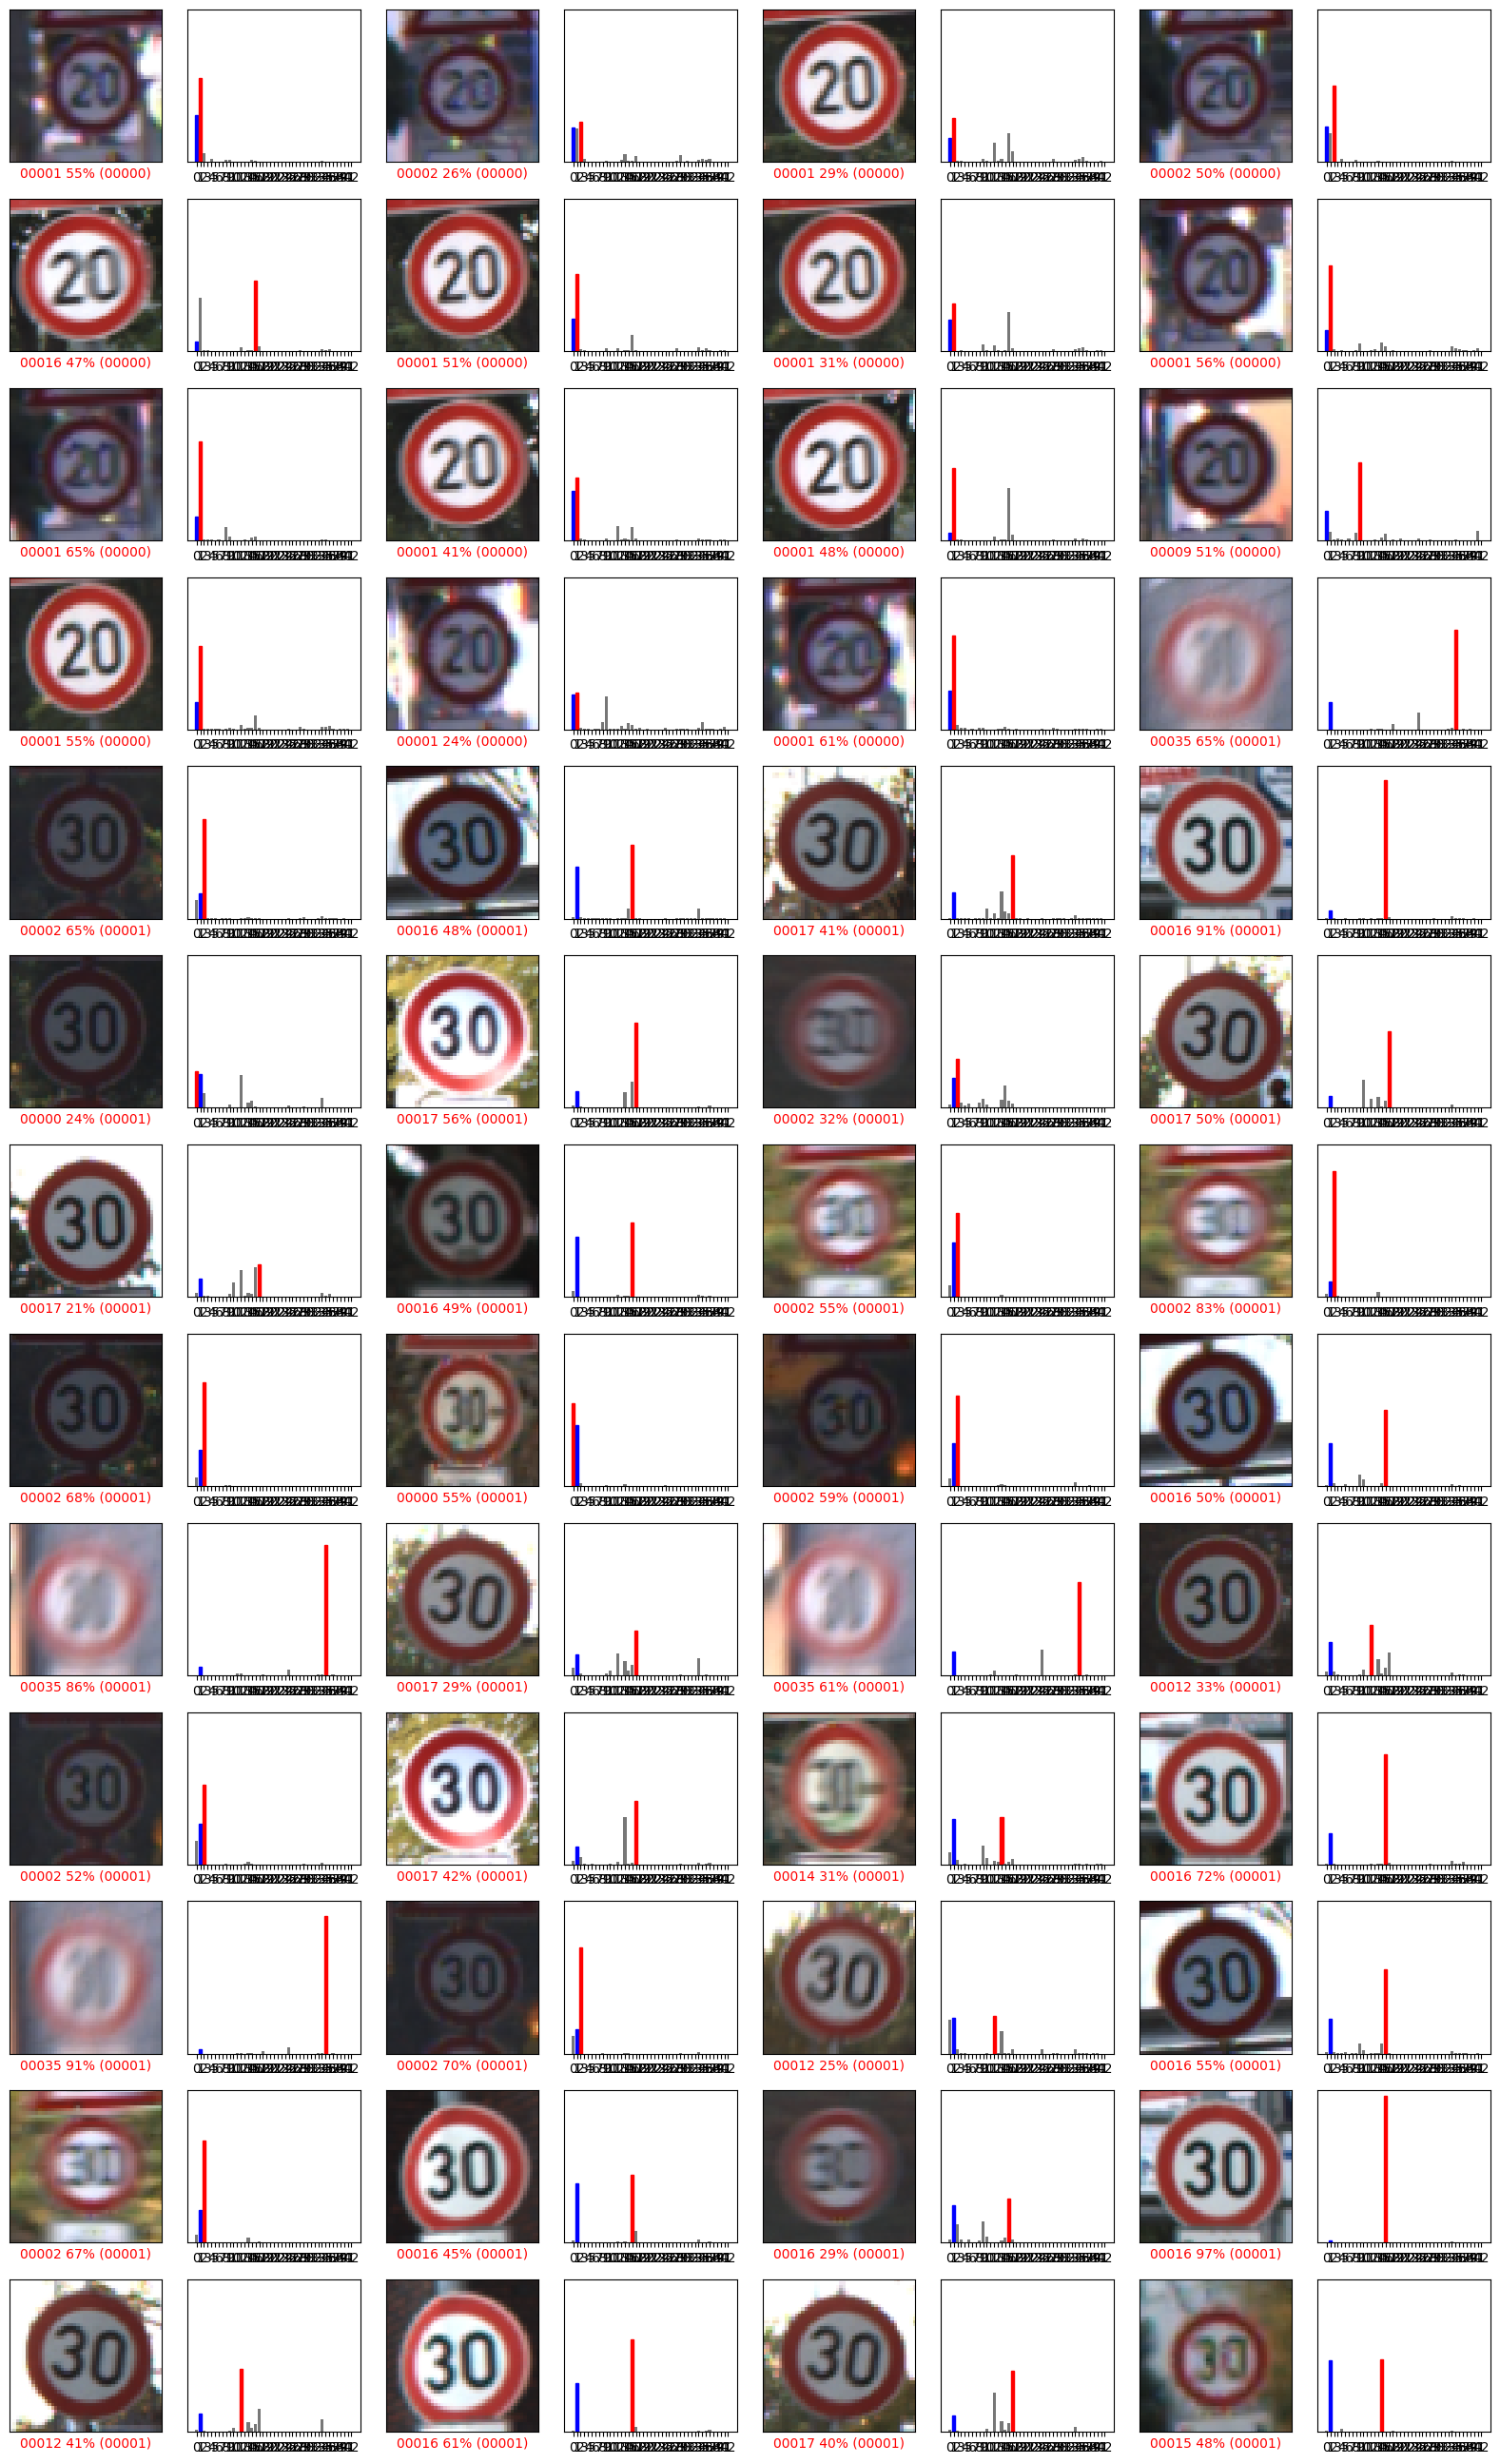

In [43]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   